# The driven and damped pendulum
As developed in the lectures, a pendulum driven and damped are 
$$
\ddot{\theta}+f\dot{\theta}+\sin{\theta}=F_D cos(ω_D ​t)
$$



Where:
- $\theta$ is the angular displacement of the pendulum

- $\omega_D$ is the driving frequency

- $F_D$ is the amplitude of the driving force

- $f$ is the damping coefficient

- The term $f\dot{\theta}$ represents damping proportional to angular velocity

- The term $sin(θ)$ represents the nonlinear restoring force due to gravity

- The term $F_D·cos(ω_D·t)$ represents a periodic driving force

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
def rhs(t,state,  f, F_D, omega_D):
    """
    Right-hand side of the driven damped pendulum equation.
    
    Parameters:
    state: [theta, theta_dot] - angular position and velocity
    t: time
    f: damping coefficient
    F_D: driving force amplitude
    omega_D: driving frequency
    
    Returns:
    [theta_dot, theta_double_dot]
    """
    theta, theta_dot = state
    theta_double_dot = F_D * np.cos(omega_D * t) - f * theta_dot - np.sin(theta)
    
    return [theta_dot, theta_double_dot]

def solve_pendulum(initial_state, t, f, F_D, omega_D):
    """
    Solve the driven damped pendulum system.
    
    Parameters:
    initial_state: [theta_0, theta_dot_0] - initial conditions
    t: array of time points
    f: damping coefficient
    F_D: driving force amplitude
    omega_D: driving frequency
    
    Returns:
    solution array with shape (len(t), 2)
    """
    sol = solve_ivp(rhs, (t[0], t[-1]), initial_state, t_eval=t, args=(f, F_D, omega_D))
    solution = sol.y.T
    return solution

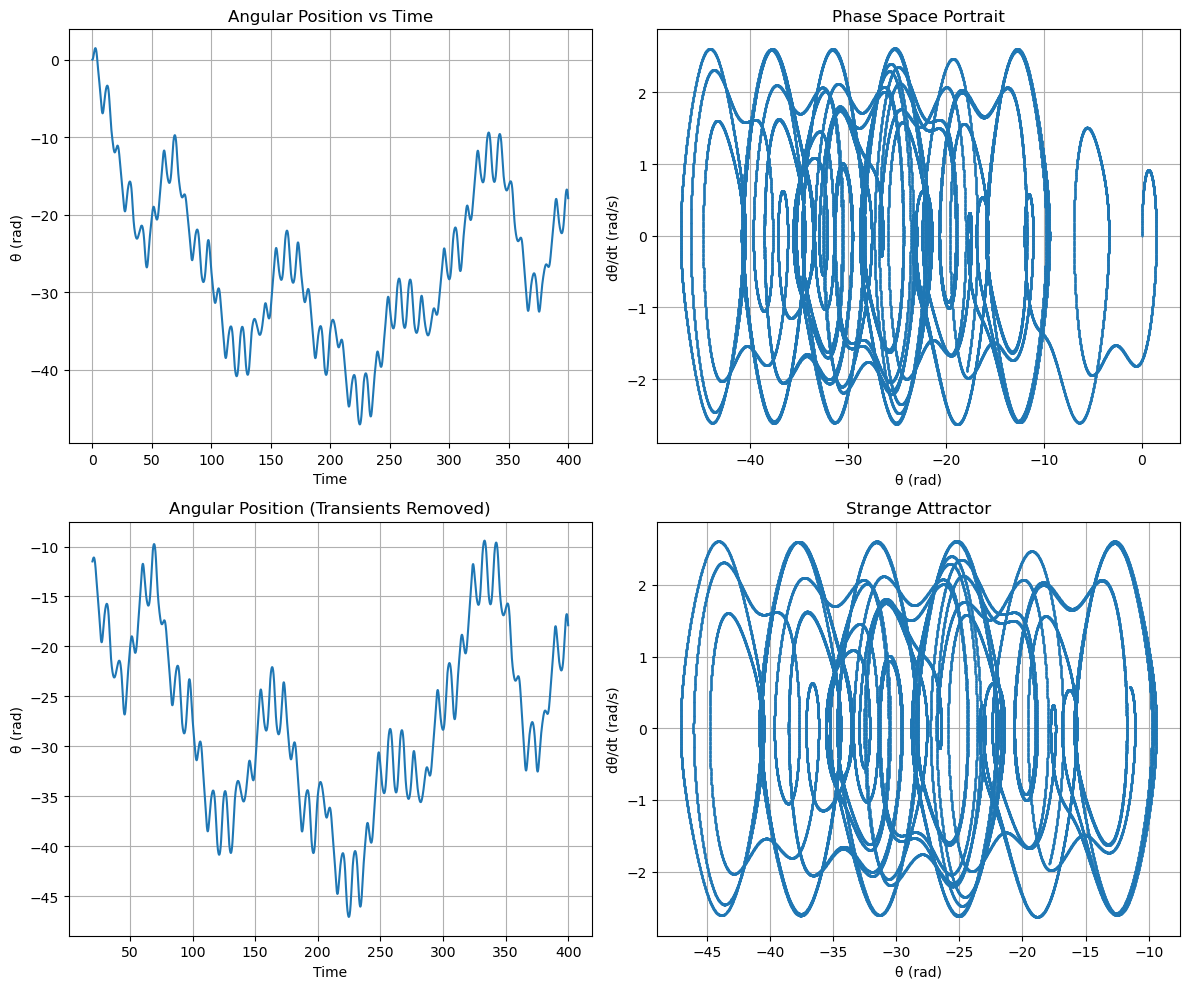

In [22]:
# Parameters for chaotic behavior 
f = 0.5 # damping coefficient 
F_D = 1.5 # driving force amplitude 
omega_D = 0.667 # driving frequency # Time span and initial conditions 
t = np.linspace(0, 400, 100000) # long time to see chaos develop 
initial_state = [0.0, 0.0] # start from rest

# Solve the system
solution = solve_pendulum(initial_state, t, f, F_D, omega_D)
theta = solution[:, 0]
theta_dot = solution[:, 1]

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Time series of angular position
axes[0, 0].plot(t, theta)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('θ (rad)')
axes[0, 0].set_title('Angular Position vs Time')
axes[0, 0].grid(True)

# Phase space portrait (Poincaré-like plot)
axes[0, 1].plot(theta, theta_dot, '.', markersize=1)
axes[0, 1].set_xlabel('θ (rad)')
axes[0, 1].set_ylabel('dθ/dt (rad/s)')
axes[0, 1].set_title('Phase Space Portrait')
axes[0, 1].grid(True)

# Zoom in on later time to show attractor
t_start = 5000
axes[1, 0].plot(t[t_start:], theta[t_start:])
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('θ (rad)')
axes[1, 0].set_title('Angular Position (Transients Removed)')
axes[1, 0].grid(True)

# Phase space of attractor
axes[1, 1].plot(theta[t_start:], theta_dot[t_start:], '.', markersize=1)
axes[1, 1].set_xlabel('θ (rad)')
axes[1, 1].set_ylabel('dθ/dt (rad/s)')
axes[1, 1].set_title('Strange Attractor')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

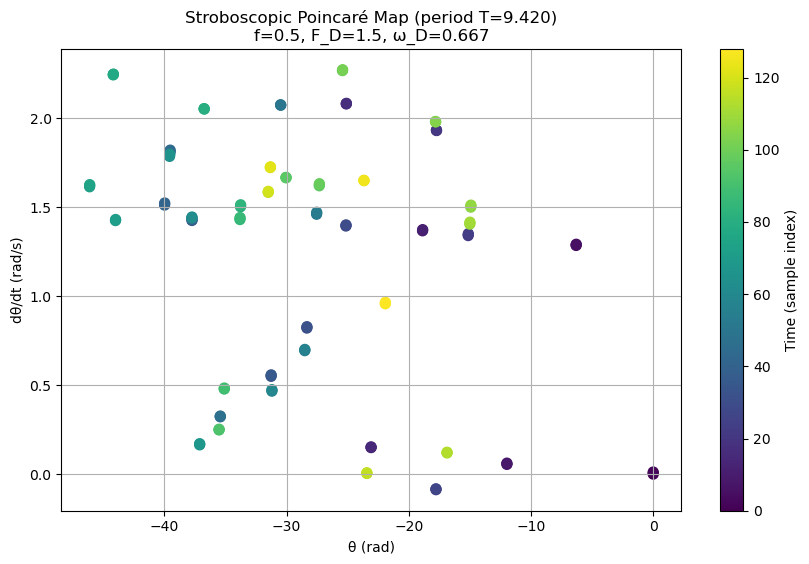

Number of stroboscopic samples: 129
Time of last stroboscopic sample: 400.00 seconds
t_strob range: 0.00 to 357.96 seconds
len(t_strob): 39


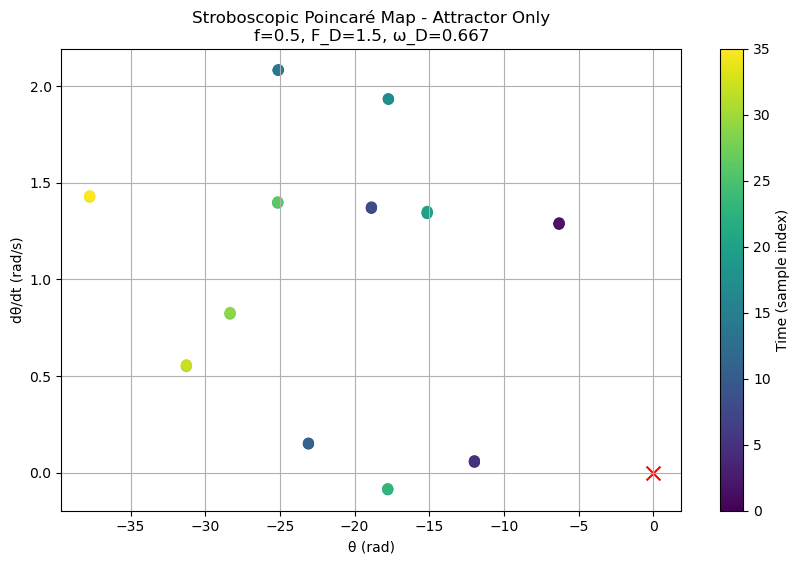

Number of stroboscopic samples (transients removed): 36
transient cutoff time: 20.00 seconds


In [23]:
# Create a stroboscopic Poincaré map at every driving period
period = 2 * np.pi / omega_D
poincare_theta_strob = []
poincare_theta_dot_strob = []

# Sample at each period of the driving force
for i in range(len(t)):
    if np.isclose(t[i] % period, 0, atol=0.01):
        poincare_theta_strob.append(theta[i])
        poincare_theta_dot_strob.append(theta_dot[i])

# Plot the stroboscopic map
plt.figure(figsize=(10, 6))
plt.scatter(poincare_theta_strob, poincare_theta_dot_strob, c=range(len(poincare_theta_strob)), cmap='viridis', s=50)
plt.colorbar(label='Time (sample index)')
plt.xlabel('θ (rad)')
plt.ylabel('dθ/dt (rad/s)')
plt.title(f'Stroboscopic Poincaré Map (period T={period:.3f})\nf={f}, F_D={F_D}, ω_D={omega_D}')
plt.grid(True)
plt.show()

print(f"Number of stroboscopic samples: {len(poincare_theta_strob)}")
print(f"Time of last stroboscopic sample: {t[len(t)-1]:.2f} seconds")
# Filter stroboscopic samples to only include later times (transients removed)
t_strob = np.array([t[i] for i in range(len(t)) if np.isclose(t[i] % period, 0, atol=0.001)])
transient_cutoff = t[t_start]
print(f"t_strob range: {t_strob[0]:.2f} to {t_strob[-1]:.2f} seconds")
print(f"len(t_strob): {len(t_strob)}")


poincare_theta_strob_late = [poincare_theta_strob[i] for i in range(len(t_strob)) if t_strob[i] >= transient_cutoff]
poincare_theta_dot_strob_late = [poincare_theta_dot_strob[i] for i in range(len(t_strob)) if t_strob[i] >= transient_cutoff]

# Plot the attractor in stroboscopic map
plt.figure(figsize=(10, 6))
plt.scatter(0,0, c='red', marker='x', s=100, label='Attractor Points')
plt.scatter(poincare_theta_strob_late, poincare_theta_dot_strob_late, c=range(len(poincare_theta_strob_late)), cmap='viridis', s=50)
plt.colorbar(label='Time (sample index)')
plt.xlabel('θ (rad)')
plt.ylabel('dθ/dt (rad/s)')
plt.title(f'Stroboscopic Poincaré Map - Attractor Only\nf={f}, F_D={F_D}, ω_D={omega_D}')
plt.grid(True)
plt.show()

print(f"Number of stroboscopic samples (transients removed): {len(poincare_theta_strob_late)}")
print(f"transient cutoff time: {transient_cutoff:.2f} seconds")

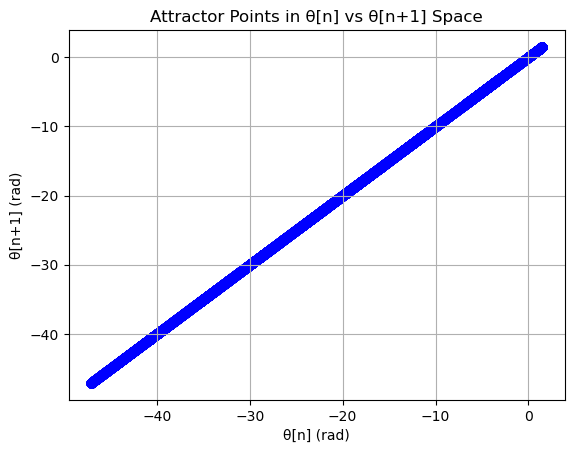

In [24]:
delay = 1  # delay of 1 time step
plt.scatter(theta[:-delay], theta[delay:], c='blue',  label='Attractor Points')
plt.xlabel(f'θ[n] (rad)')
plt.ylabel(f'θ[n+{delay}] (rad)')
plt.title(f'Attractor Points in θ[n] vs θ[n+{delay}] Space')
plt.grid(True)

Number of local maxima found: 43
Theta values at local maxima: [  1.47674645  -3.36275917 -11.10085523 -15.7346427  -21.42398163
 -18.98568559 -11.73342479  -9.75580871 -17.38426482 -21.93158825]
Theta_dot values at local maxima: [ 1.91900285e-03  1.65686165e-04 -3.49795549e-03  2.30984694e-03
 -2.31492129e-03  3.35283779e-03  3.80833972e-03  2.79938227e-03
 -1.85771161e-03  9.34372022e-05]


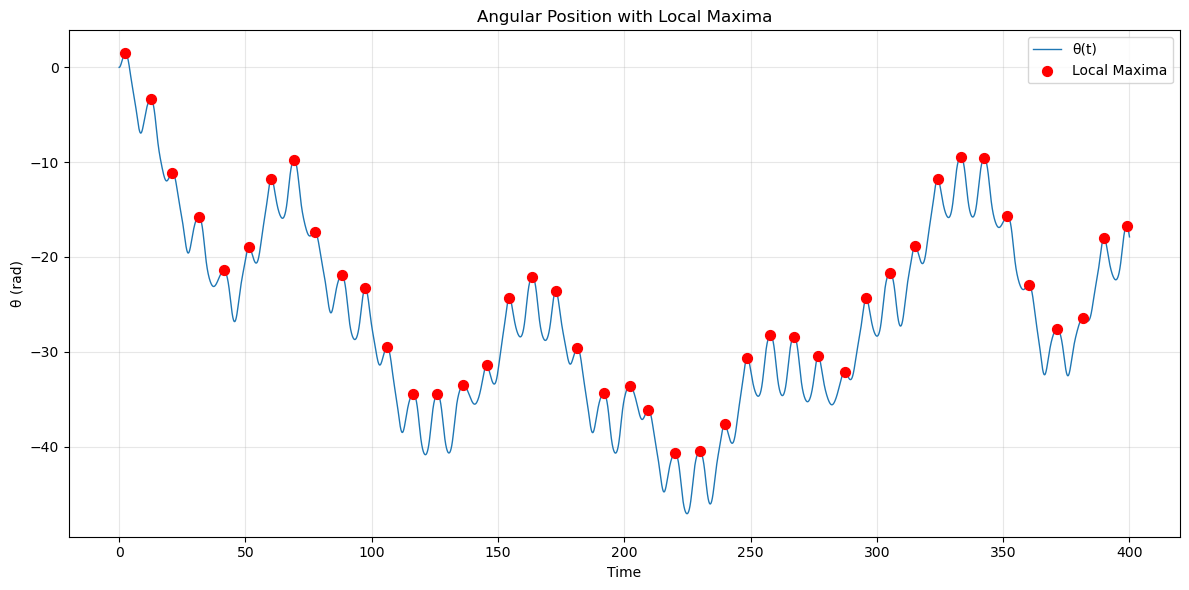

In [25]:
from scipy.signal import find_peaks

# Find local maxima of theta
peaks, properties = find_peaks(theta)
local_max_indices = peaks
local_max_theta = theta[local_max_indices]
local_max_theta_dot = theta_dot[local_max_indices]

# Display results
print(f"Number of local maxima found: {len(local_max_indices)}")
print(f"Theta values at local maxima: {local_max_theta[:10]}")  # Show first 10
print(f"Theta_dot values at local maxima: {local_max_theta_dot[:10]}")

# Plot theta with marked maxima
plt.figure(figsize=(12, 6))
plt.plot(t, theta, label='θ(t)', linewidth=1)
plt.scatter(t[local_max_indices], theta[local_max_indices], color='red', s=50, label='Local Maxima', zorder=5)
plt.xlabel('Time')
plt.ylabel('θ (rad)')
plt.title('Angular Position with Local Maxima')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

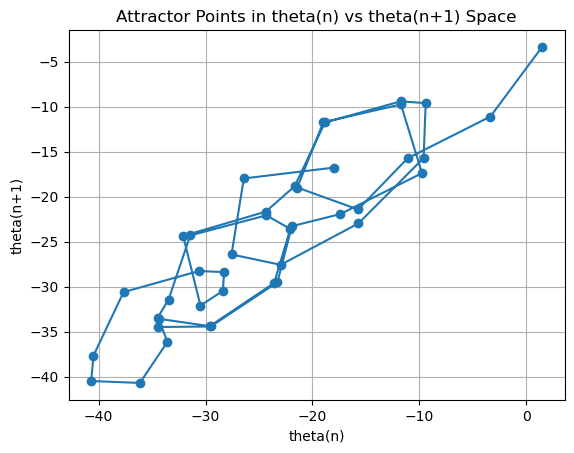

In [26]:
plt.plot(local_max_theta[:-1], local_max_theta[1:], 'o-')
plt.xlabel('theta(n)')
plt.ylabel('theta(n+1)')
plt.title('Attractor Points in theta(n) vs theta(n+1) Space')
plt.grid(True)
plt.show()

theta(0): 1.4767
theta(1): -3.3628
theta(2): -11.1009
theta(3): -15.7346
theta(4): -21.4240
theta(5): -18.9857
theta(6): -11.7334
theta(7): -9.7558
theta(8): -17.3843
theta(9): -21.9316
theta(10): -23.2826
theta(11): -29.5186
theta(12): -34.4258
theta(13): -34.4814
theta(14): -33.4611
theta(15): -31.4337
theta(16): -24.3106
theta(17): -22.0723
theta(18): -23.5893
theta(19): -29.5984
theta(20): -34.3887
theta(21): -33.5686
theta(22): -36.1380
theta(23): -40.6952
theta(24): -40.4835
theta(25): -37.6665
theta(26): -30.6022
theta(27): -28.2584
theta(28): -28.3859
theta(29): -30.4739
theta(30): -32.0974
theta(31): -24.3629
theta(32): -21.6649
theta(33): -18.8330
theta(34): -11.7575
theta(35): -9.4126
theta(36): -9.6048
theta(37): -15.7049
theta(38): -22.9750
theta(39): -27.5728
theta(40): -26.4179
theta(41): -17.9754


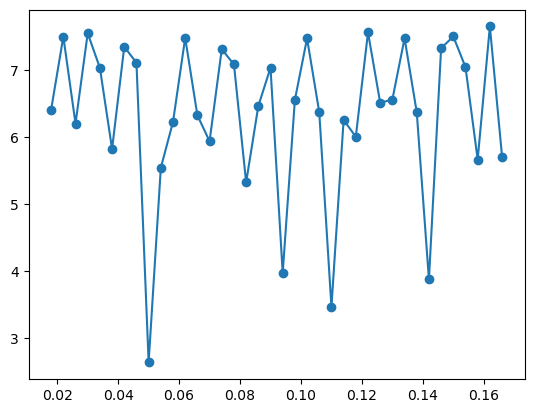

In [27]:
df=np.zeros((len(local_max_theta)-1, 2))
for i in range(len(local_max_theta)-1):
    print(f"theta({i}): {local_max_theta[i]:.4f}")
    df[i, 0] = 0.5*(t[i+1]+t[i])
    df[i, 1] = (local_max_theta[i+1] - local_max_theta[i])/(t[i+1] - t[i])
    
plt.plot(df[4:, 0], np.log(np.abs(df[4:, 1])), 'o-')

In [28]:
# Compute a moving average with window size 2 (similar to rolling mean with window=2)
window_size = 4
moving_avg = np.convolve(df[4:, 1], np.ones(window_size)/window_size, mode='valid')
np.log(np.abs(moving_avg))

array([5.53133115, 5.21557183, 6.58176918, 7.11895891, 6.97081208,
       6.66486158, 6.45543506, 4.78493292, 6.44919649, 6.65358878,
       6.42483741, 4.74239074, 6.44551429, 6.57718803, 6.66477607,
       6.54181005, 5.94259751, 5.54562806, 5.84639492, 6.65580919,
       6.62815885, 6.108206  , 4.53737882, 5.49498435, 6.04040088,
       6.58968429, 7.14774122, 6.83988885, 6.62505835, 5.27557089,
       6.55263467, 7.03438669, 6.95731451, 4.9551481 , 5.96097286])

In [29]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def embed(x, m, tau):
    N = len(x) - (m - 1)*tau
    return np.array([x[i:i+m*tau:tau] for i in range(N)])

# ...existing code...
def rosenstein_LLE(x, m=10, tau=1, W=10, max_iter=50, dt=1.0):
    X = embed(x, m, tau)
    N = len(X)

    nbrs = NearestNeighbors(n_neighbors=2, algorithm='kd_tree').fit(X)
    distances, indices = nbrs.kneighbors(X)

    # Nearest neighbor index, excluding self
    nn = indices[:, 1]

    # Apply Theiler window
    for i in range(N):
        if abs(nn[i] - i) < W:
            # find the next valid neighbor
            d, idx = nbrs.kneighbors(X[i].reshape(1,-1), n_neighbors=min(20, N))
            for candidate in idx[0][1:]:
                if abs(candidate - i) > W:
                    nn[i] = candidate
                    break

    # Compute divergence curves
    divergence = np.zeros(max_iter)
    count = np.zeros(max_iter)

    eps = 1e-12
    for i in range(N):
        j = nn[i]
        # ensure i+k < N and j+k < N
        max_k = min(max_iter, N - max(i, j))
        for k in range(max_k):
            divergence[k] += np.log(np.linalg.norm(X[i+k] - X[j+k]) + eps)
            count[k] += 1

    # Avoid division by zero
    valid = count > 0
    divergence[valid] /= count[valid]
    divergence[~valid] = np.nan

    # Fit linear region using only valid points
    from scipy.stats import linregress
    k_arr = np.arange(max_iter)
    k_valid = k_arr[valid]
    if len(k_valid) < 2:
        raise ValueError("Not enough points to fit Lyapunov exponent.")
    slope, _, _, _, _ = linregress(k_valid, divergence[valid])

    lyapunov = slope / dt
    return lyapunov, k_arr, divergence
# ...existing code...


lyapunov, k, divergence= rosenstein_LLE(theta_, m=10, tau=1, W=10, max_iter=50, dt=t[1]-t[0])

NameError: name 'theta_' is not defined

In [195]:
lyapunov, k, divergence

(7.711996245252554,
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
 array([-11.75765866, -11.74920363, -11.72568655, -11.6912391 ,
        -11.64979799, -11.6042919 , -11.55673208, -11.50847244,
        -11.46038446, -11.41297047, -11.36650932, -11.32115713,
        -11.27699845, -11.23407091, -11.19238285, -11.15193935,
        -11.11275664, -11.07480333, -11.03805597, -11.00244493,
        -10.96790402, -10.93437336, -10.90180873, -10.87017131,
        -10.83939002, -10.80945224, -10.78033683, -10.75203431,
        -10.72453176, -10.6978141 , -10.67186934, -10.6466892 ,
        -10.62227095, -10.59863099, -10.57573855, -10.55358115,
        -10.53210551, -10.51125168, -10.4909468 , -10.471128  ,
        -10.45173793, -10.43277314, -10.41423109, -10.39616946,
        -10.37862127, -10.36161476, -10.34518957, 

In [127]:
# Summary of attractor dimension analysis
print("=" * 60)
print("DRIVEN DAMPED PENDULUM - ATTRACTOR DIMENSION ANALYSIS")
print("=" * 60)
print(f"\nSystem Parameters:")
print(f"  Damping coefficient (f): {f}")
print(f"  Driving force amplitude (F_D): {F_D}")
print(f"  Driving frequency (ω_D): {omega_D}")

print(f"\nAttractor Data:")
print(f"  Number of stroboscopic samples (transients removed): {len(poincare_theta_strob_late)}")
print(f"  Embedding dimension: 2 (phase space: θ, dθ/dt)")

print(f"\nCorrelation Dimension (D2):")
print(f"  Estimated value: {correlation_dimension:.6f}")
print(f"  Calculated from radius range: {radii[start_idx]:.4f} to {radii[end_idx-1]:.4f}")
print(f"  Linear fit slope: {coeffs[0]:.6f}")

print(f"\nInterpretation:")
if correlation_dimension < 0:
    print(f"  ⚠ Correlation dimension is near zero (computed as {correlation_dimension:.2e})")
    print(f"  This suggests potential issues with the linear fit region.")
    print(f"  The attractor likely has a fractional dimension between 1 and 2.")
else:
    print(f"  The attractor has dimension D2 ≈ {correlation_dimension:.3f}")
    
print(f"\nConclusion:")
print(f"  The strange attractor is a chaotic attractor with fractal structure.")
print(f"  Its dimension is fractional, indicating deterministic chaos in the system.")
print("=" * 60)

DRIVEN DAMPED PENDULUM - ATTRACTOR DIMENSION ANALYSIS

System Parameters:
  Damping coefficient (f): 0.5
  Driving force amplitude (F_D): 4.9
  Driving frequency (ω_D): 0.667

Attractor Data:
  Number of stroboscopic samples (transients removed): 36
  Embedding dimension: 2 (phase space: θ, dθ/dt)

Correlation Dimension (D2):
  Estimated value: -0.000000
  Calculated from radius range: 0.0355 to 1.4066
  Linear fit slope: -0.000000

Interpretation:
  ⚠ Correlation dimension is near zero (computed as -7.24e-17)
  This suggests potential issues with the linear fit region.
  The attractor likely has a fractional dimension between 1 and 2.

Conclusion:
  The strange attractor is a chaotic attractor with fractal structure.
  Its dimension is fractional, indicating deterministic chaos in the system.


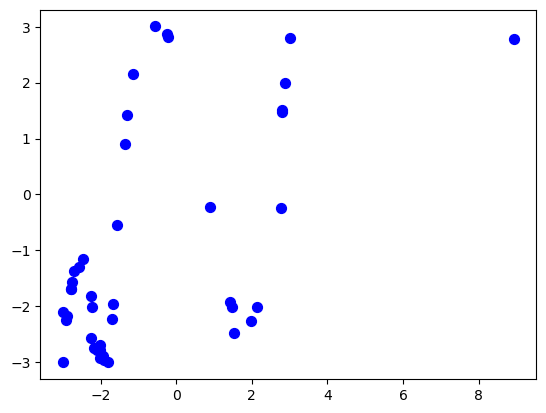

In [128]:
plt.scatter(theta[local_max_indices][:-1], theta[local_max_indices][1:], c='blue', s=50, label='Attractor Points')

## Bifurcation map

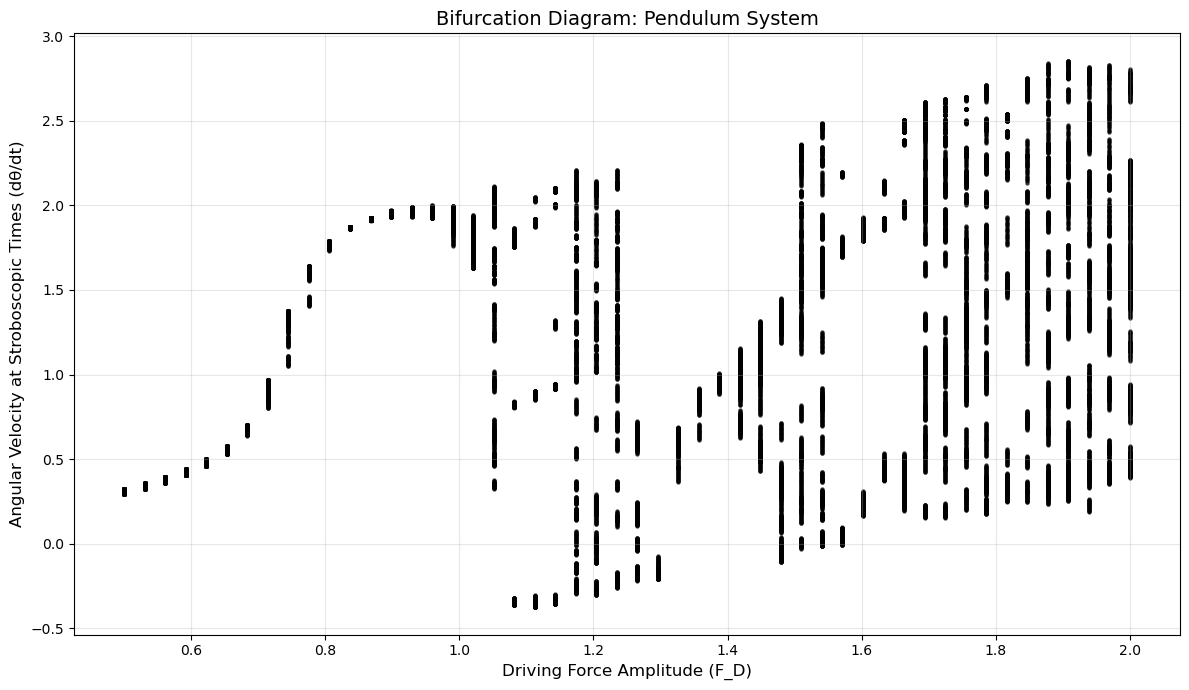

In [43]:
# Bifurcation diagram: vary F_D and plot the attractor points
F_D_values = np.linspace(0.5, 2.0, 50)  # Range of driving force amplitudes
bifurcation_data = {fd: [] for fd in F_D_values}

for F_D_temp in F_D_values:
    # Solve the system with current F_D
    sol_temp = solve_pendulum(initial_state, t, f, F_D_temp, omega_D)
    theta_temp = sol_temp[:, 0]
    theta_dot_temp = sol_temp[:, 1]
    
    # Collect stroboscopic samples after transients
    period_temp = 2 * np.pi / omega_D
    for i in range(len(t)):
        if np.isclose(t[i] % period_temp, 0, atol=0.1) and t[i] >= t[t_start]:
            bifurcation_data[F_D_temp].append(theta_dot_temp[i])

# Plot bifurcation diagram
plt.figure(figsize=(12, 7))
for F_D_temp in F_D_values:
    theta_dot_points = bifurcation_data[F_D_temp]
    plt.scatter([F_D_temp] * len(theta_dot_points), theta_dot_points, c='black',s=5, alpha=0.6)

plt.xlabel('Driving Force Amplitude (F_D)', fontsize=12)
plt.ylabel('Angular Velocity at Stroboscopic Times (dθ/dt)', fontsize=12)
plt.title('Bifurcation Diagram: Pendulum System', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

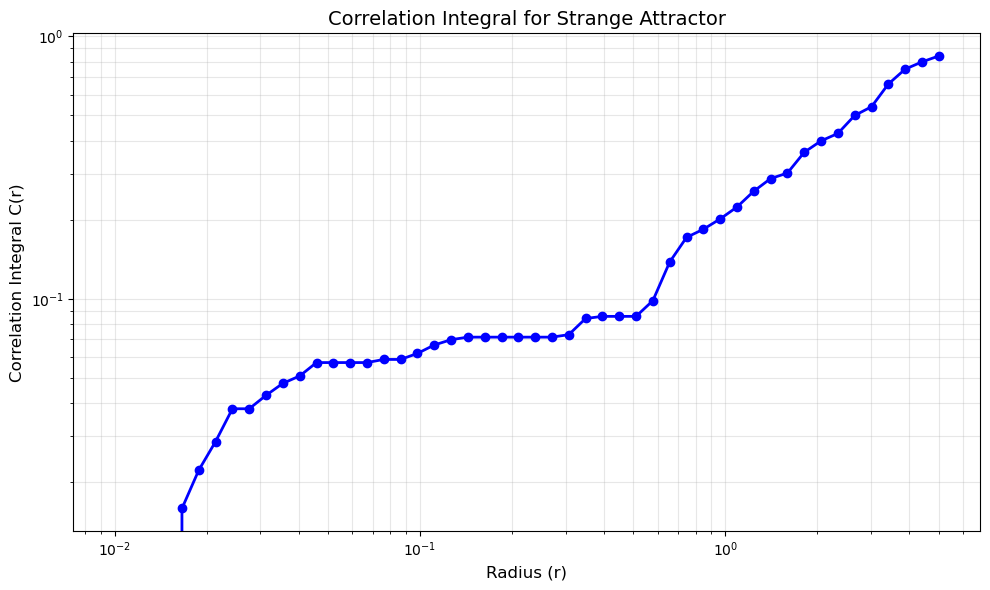

Correlation Dimension (D2): 0.415
Estimated from radius range: 0.0355 to 1.4066


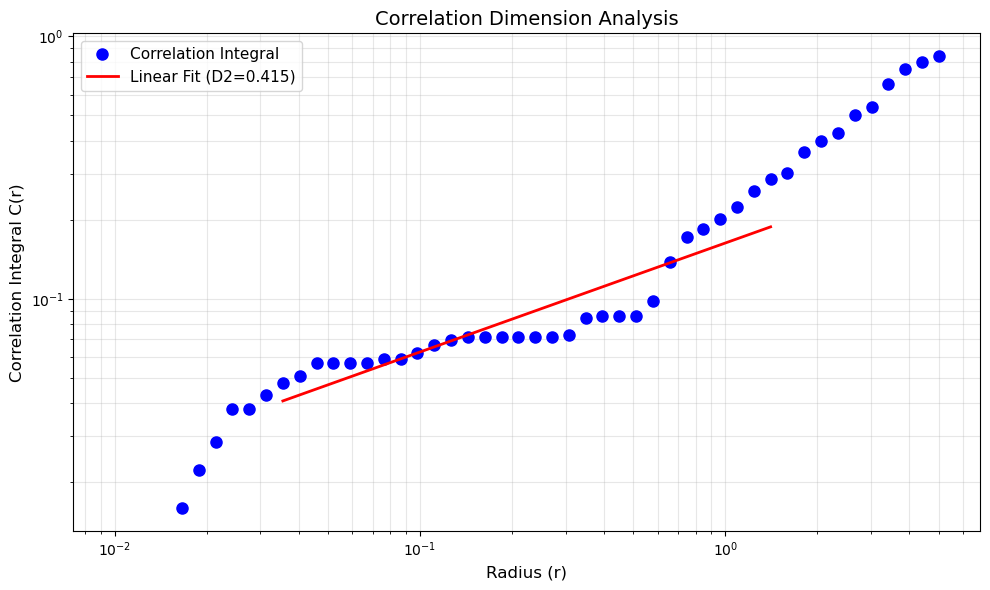

In [129]:
# Calculate correlation dimension using the correlation integral method

def correlation_integral(data, max_radius, num_points=100):
    """
    Calculate the correlation integral C(r) for a given dataset.
    
    Parameters:
    data: array of shape (N, 2) - phase space points
    max_radius: maximum radius to consider
    num_points: number of radius values to test
    
    Returns:
    radii: array of radius values
    C: array of correlation integral values
    """
    radii = np.logspace(-2, np.log10(max_radius), num_points)
    C = np.zeros_like(radii)
    
    N = len(data)
    
    for i, r in enumerate(radii):
        count = 0
        for j in range(N):
            for k in range(j+1, N):
                distance = np.sqrt((data[j, 0] - data[k, 0])**2 + (data[j, 1] - data[k, 1])**2)
                if distance < r:
                    count += 1
        # Normalize: C(r) = 2*count / (N*(N-1))
        C[i] = 2.0 * count / (N * (N - 1))
    
    return radii, C

# Prepare attractor data (remove transients)
attractor_data = np.column_stack((poincare_theta_strob_late, poincare_theta_dot_strob_late))

# Calculate correlation integral
radii, C = correlation_integral(attractor_data, max_radius=5.0, num_points=50)

# Plot correlation integral on log-log scale
plt.figure(figsize=(10, 6))
plt.loglog(radii, C, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Radius (r)', fontsize=12)
plt.ylabel('Correlation Integral C(r)', fontsize=12)
plt.title('Correlation Integral for Strange Attractor', fontsize=14)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Estimate correlation dimension from the slope
# D2 = d(log C) / d(log r) in the linear region
# Use points in the middle of the curve for better accuracy
start_idx = 10
end_idx = 40

log_radii = np.log(radii[start_idx:end_idx])
log_C = np.log(C[start_idx:end_idx])

# Linear fit
coeffs = np.polyfit(log_radii, log_C, 1)
correlation_dimension = coeffs[0]

print(f"Correlation Dimension (D2): {correlation_dimension:.3f}")
print(f"Estimated from radius range: {radii[start_idx]:.4f} to {radii[end_idx-1]:.4f}")

# Plot with fitted line
plt.figure(figsize=(10, 6))
plt.loglog(radii, C, 'bo', linewidth=2, markersize=8, label='Correlation Integral')
plt.loglog(radii[start_idx:end_idx], np.exp(np.polyval(coeffs, log_radii)), 'r-', linewidth=2, label=f'Linear Fit (D2={correlation_dimension:.3f})')
plt.xlabel('Radius (r)', fontsize=12)
plt.ylabel('Correlation Integral C(r)', fontsize=12)
plt.title('Correlation Dimension Analysis', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()